# Internship Project — Sales Forecasting by Product Category

## Context
The objective of this internship project is to forecast the quantity of products sold by category over a future prediction horizon of X days, while making the prediction Y days in advance.

### Step 1: Load the raw data

We use the UCI **Online Retail** dataset, which contains all transactions
from a UK-based online gift retailer between *December 2010* and *December
2011* (541,909 rows). Each row is one product line within one invoice,
with the product description, quantity sold, unit price, invoice date,
customer ID, and country.

In [14]:
import pandas as pd

In [16]:
df = pd.read_excel("Online Retail.xlsx")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Step 2: Load the category mapping

Individual product descriptions (e.g. "WHITE HANGING HEART T-LIGHT
HOLDER") are too granular to forecast one by one — there are over 4,000
distinct products. We use a category mapping (provided for this
internship) that groups similar products into ~55 broader categories
(e.g. "Tealight Holders & Sets"), which gives us series with enough
volume and regularity to model.

In [18]:
import json

with open("products_to_categories.json") as f:
    categories = json.load(f)

print(f"Number of mapped products: {len(categories)}")
# peek at a few entries
list(categories.items())[:5]

Number of mapped products: 3866


[('bird house hot water bottle', 'Hot Water Bottles'),
 ('charlie + lola red hot water bottle', 'Hot Water Bottles'),
 ('charlie lola blue hot water bottle', 'Hot Water Bottles'),
 ('charlie+lola pink hot water bottle', 'Hot Water Bottles'),
 ('charlie+lola red hot water bottle', 'Hot Water Bottles')]

### Step 3: Clean the data

Before aggregating, we remove rows that don't represent real sales:
- Cancelled orders (invoice numbers starting with "C") — these are
  returns, not sales.
- Administrative line items such as postage, discounts, and bank
  charges, which aren't products.
- Rows with zero or negative quantity/price.

In [20]:
# Drop cancellations (invoice numbers starting with "C")
df_clean = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

# Drop administrative line items (postage, discounts, fees, manual adjustments)
admin_codes = ["POST", "D", "M", "C2", "DOT", "BANK CHARGES", "CRUK", "S", "PADS"]
df_clean = df_clean[~df_clean["StockCode"].astype(str).str.upper().isin(admin_codes)]

# Keep only positive quantity and positive price
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 541909
Rows after cleaning: 527792


### Step 4: Map products to categories

Each cleaned transaction's product description is matched (case-
insensitive) against the category mapping from Step 2, so every row is
tagged with its category. Descriptions with no match (a small fraction,
mostly non-product noise) are labeled "Unclassified".

In [25]:
# Normalize description text (lowercase, strip whitespace) to match the JSON keys
df_clean["desc_norm"] = df_clean["Description"].astype(str).str.strip().str.lower()

# Look up each description in the category dictionary; anything unmatched becomes "Unclassified"
df_clean["Category"] = df_clean["desc_norm"].map(categories).fillna("Unclassified")

# Check how well the mapping worked
unclassified_share = (df_clean["Category"] == "Unclassified").mean()
print(f"Share of rows Unclassified: {unclassified_share*100:.2f}%")

df_clean[["Description", "Category"]].head(10)

Share of rows Unclassified: 0.15%


,Description,Category
0,WHITE HANGING HEART T-LIGHT HOLDER,Tealight Holders & Sets
1,WHITE METAL LANTERN,Lanterns
2,CREAM CUPID HEARTS COAT HANGER,"Coat Racks, Hooks & Hangers"
3,KNITTED UNION FLAG HOT WATER BOTTLE,Hot Water Bottles
4,RED WOOLLY HOTTIE WHITE HEART.,Hot Water Bottles
5,SET 7 BABUSHKA NESTING BOXES,Miscellaneous
6,GLASS STAR FROSTED T-LIGHT HOLDER,Tealight Holders & Sets
7,HAND WARMER UNION JACK,Hand Warmers & Umbrellas
8,HAND WARMER RED POLKA DOT,Hand Warmers & Umbrellas
9,ASSORTED COLOUR BIRD ORNAMENT,Miscellaneous


### Step 5: Aggregate to daily category-level sales

We sum quantities by day and category to get one time series per
category. Days with no recorded sales for a given category are
explicitly filled in as zero — this matters because gaps would
otherwise be invisible to a forecasting model and bias it.

In [28]:
# Extract just the date (drop the time) and compute revenue per line
df_clean["Date"] = df_clean["InvoiceDate"].dt.date
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Sum quantity, revenue, and count distinct orders, per day per category
daily = (
    df_clean.groupby(["Date", "Category"])
    .agg(Quantity=("Quantity", "sum"), Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
    .reset_index()
) #For each combination of date and category, we have the total quantity sold, total revenue, and number of distinct orders

# Build a complete grid of every (date, category) combination, so missing days become explicit zeros
daily["Date"] = pd.to_datetime(daily["Date"])
all_dates = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
all_categories = daily["Category"].unique()
full_index = pd.MultiIndex.from_product([all_dates, all_categories], names=["Date", "Category"])

daily = daily.set_index(["Date", "Category"]).reindex(full_index, fill_value=0).reset_index()

print(f"Date range: {daily['Date'].min().date()} to {daily['Date'].max().date()}")
print(f"Number of days: {daily['Date'].nunique()}")
print(f"Number of categories: {daily['Category'].nunique()}")
daily.head(10)

Date range: 2010-12-01 to 2011-12-09
Number of days: 374
Number of categories: 55


,Date,Category,Quantity,Revenue,Orders
0,2010-12-01,"Bag Charms, Key Rings & Phone Charms",1,1.66,1
1,2010-12-01,"Bags, Purses & Backpacks",683,1338.68,26
2,2010-12-01,"Baskets, Hampers & Wicker",83,336.66,14
3,2010-12-01,Cake Cases & Baking Accessories,879,866.83,18
4,2010-12-01,Cake Stands,160,1720.27,19
5,2010-12-01,"Candles, Incense & Matches",1226,1383.02,35
6,2010-12-01,Children's Toys & Playsets,387,906.52,23
7,2010-12-01,Christmas Decorations,1571,1597.25,25
8,2010-12-01,Clocks & Timepieces,200,874.40,10
9,2010-12-01,"Clothing, Accessories & Beauty",83,234.38,13


In [30]:
daily.to_csv("daily_category_sales.csv", index=False)

### Step 6: Exploratory data analysis

Before modeling, we visualize the daily sales to spot trend, seasonality,
and any irregularities that should inform model choice.

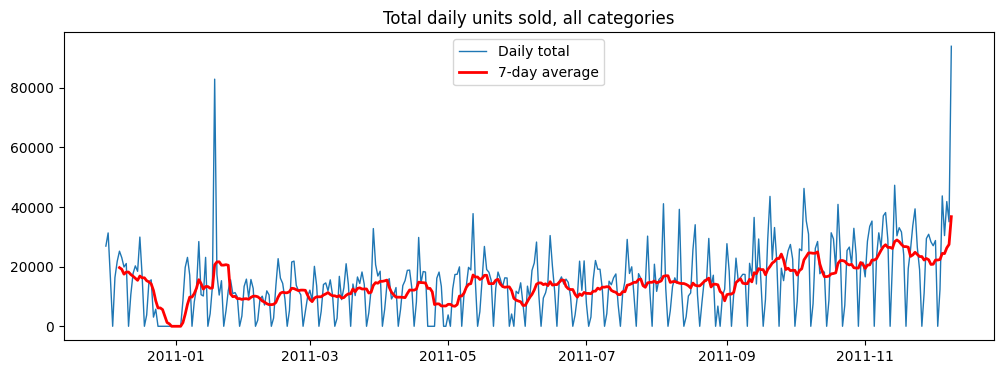

weekday
Monday       16432.830189
Tuesday      20984.094340
Wednesday    18982.277778
Thursday     22363.222222
Friday       16497.129630
Saturday         0.000000
Sunday        8878.056604
Name: Quantity, dtype: float64


In [40]:
import matplotlib.pyplot as plt

overall = daily.groupby("Date")["Quantity"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(overall.index, overall.values, lw=1, label="Daily total")
ax.plot(overall.index, overall.rolling(7).mean(), lw=2, color="red", label="7-day average")
ax.set_title("Total daily units sold, all categories")
ax.legend()
plt.show()

# Average sales by day of week
overall_df = overall.reset_index()
overall_df["weekday"] = overall_df["Date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = overall_df.groupby("weekday")["Quantity"].mean().reindex(order)
print(weekday_avg)

### Step 7: Stationarity Test
For the stationarity test and ACF/PACF analysis, I focus on one representative category: **Tealight Holders & Sets**.

This allows an initial analysis of the time series behavior before generalizing the same approach to other product categories.

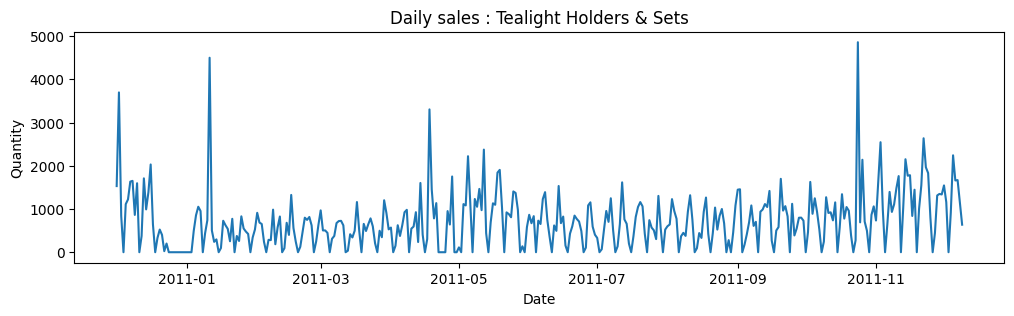

In [132]:
from statsmodels.tsa.stattools import adfuller
#From the daily dataframe, keep only Tealight Holders & Sets rows, set Date as the index, grab only the Quantity column, and sort by date
ts=daily[daily["Category"]=="Tealight Holders & Sets"].set_index("Date")["Quantity"].sort_index()

fig,ax=plt.subplots(figsize=(12,3))
ax.plot(ts)
ax.set_title("Daily sales : Tealight Holders & Sets")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity")
plt.show()

#### Observations — Tealight Holders & Sets

- **Sales evolution:** sales fluctuate throughout the year, with higher activity visible from September to the Christmas period.
- **Weekly pattern:** repeated drops and spikes suggest a possible weekly pattern. Saturday sales are equal to zero in the dataset, which may reflect a business or data collection pattern.
- **Holiday / calendar effect:** sales drop sharply around early January, possibly due to holiday-related business activity.
- **Large spikes:** some exceptional peaks may correspond to bulk orders or unusual demand events.

#### Implications for modeling

- The time series contains short-term fluctuations and possible weekly effects.
- Lag features such as `lag_1`, `lag_7`, `lag_14`, and `lag_28` may be useful.
- Rolling-window features can help capture recent sales behavior.
- Statistical models such as ARMA and SARIMA can be tested, especially to compare non-seasonal and weekly seasonal structures.

In [66]:
# ADF test
result = adfuller(ts)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("Stationary (p < 0.05)")
else:
    print("Not stationary (p >= 0.05)")

ADF Statistic: -3.3665
p-value: 0.0122
Stationary (p < 0.05)


##### Conclusion: 
The **ADF** test rejects the unit-root hypothesis for this selected category. However, the plot still shows visible weekly effects and seasonal changes in sales intensity. Therefore, both non-seasonal and seasonal models can be tested and compared empirically.

### Step 8: ACF and PACF Plots
ACF shows correlation between today's sales and past values.
PACF shows the direct correlation removing indirect effects.
Together they help choose the right lag features and SARIMA orders.

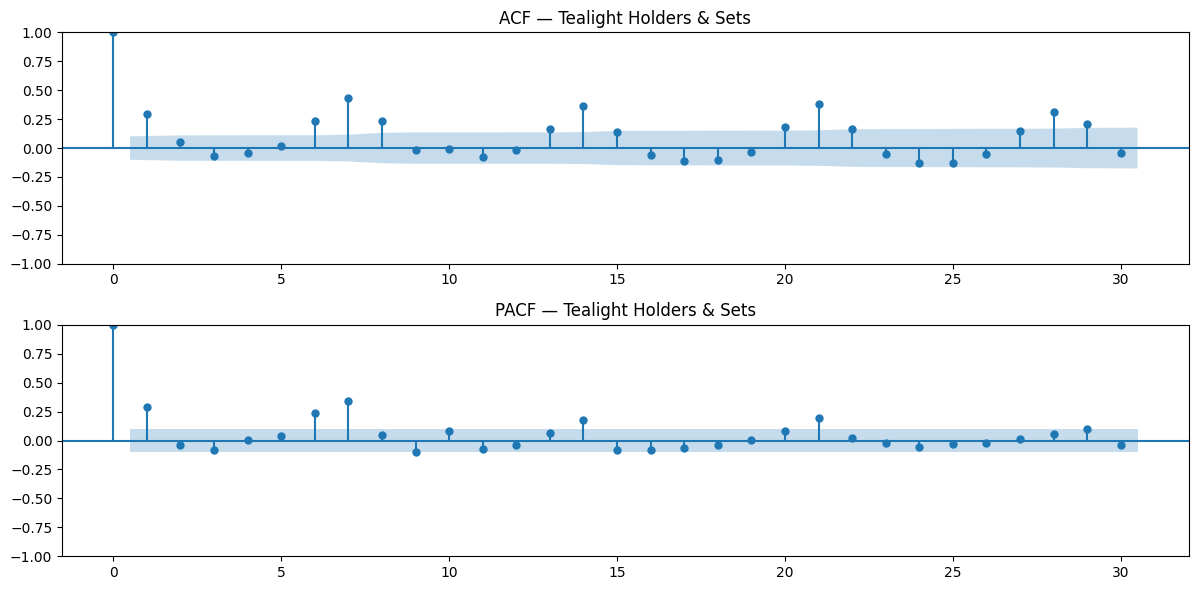

In [72]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(ts, lags=30, ax=ax1)
ax1.set_title("ACF — Tealight Holders & Sets")

plot_pacf(ts, lags=30, ax=ax2)
ax2.set_title("PACF — Tealight Holders & Sets")

plt.tight_layout()
plt.show()

#### Interpretation of ACF and PACF

The ACF and PACF plots for **Tealight Holders & Sets** show significant autocorrelation at short lags, especially at **lag 1**. This means that recent sales values contain useful information for predicting future sales.

Several significant spikes also appear around weekly-related lags, especially around **lag 7, lag 14, lag 21, and lag 28**. This suggests the presence of a possible weekly pattern in the sales series.

The ACF does not cut off sharply after the first lag, which means the series may contain both short-term dependency and seasonal effects. The PACF also shows some significant lags, especially around lag 1 and weekly lags.

#### Modeling implications

- Lag features such as `lag_1`, `lag_7`, `lag_14`, `lag_21`, and `lag_28` may be useful.
- Rolling-window features can help capture recent sales behavior.
- Since the ADF test suggests stationarity, ARMA models with `d = 0` can be tested as a first statistical benchmark.
- Because weekly effects are visible, SARIMA with seasonal period `s = 7` should also be tested and compared.
- Final model choice should be based on validation metrics, not only on ACF/PACF visual inspection.

### Step 9: Create a forecasting dataset
We create a first supervised learning dataset to predict the total quantity sold over the next *X* days, with the prediction made *Y* days in advance.

For this first experiment, we use *X=7* and *Y=7*.

In [86]:
X = 7  # prediction horizon: next 7 days
Y = 7  # prediction made 7 days in advance

target_col = f"target_X{X}_Y{Y}"

In [103]:
def create_future_target(group, X=7, Y=7):
    category = group.name
    group = group.sort_values("Date").copy()
    
    group["Category"] = category
    
    quantities = group["Quantity"].values
    targets = []

    for i in range(len(group)):
        start = i + Y
        end = i + Y + X

        if end <= len(group):
            targets.append(quantities[start:end].sum())
        else:
            targets.append(np.nan)

    group[f"target_X{X}_Y{Y}"] = targets
    return group

In [135]:
model_data = (
    daily.groupby("Category", group_keys=False)
    .apply(lambda g: create_future_target(g, X=X, Y=Y), include_groups=False)
    .reset_index(drop=True)
)

model_data.head(10)

,Date,Quantity,Revenue,Orders,Category,target_X7_Y7
0,2010-12-01,1,1.66,1,"Bag Charms, Key Rings & Phone Charms",129.0
1,2010-12-01,683,1338.68,26,"Bags, Purses & Backpacks",4657.0
2,2010-12-01,83,336.66,14,"Baskets, Hampers & Wicker",498.0
3,2010-12-01,879,866.83,18,Cake Cases & Baking Accessories,4428.0
4,2010-12-01,160,1720.27,19,Cake Stands,1028.0
5,2010-12-01,1226,1383.02,35,"Candles, Incense & Matches",5888.0
6,2010-12-01,387,906.52,23,Children's Toys & Playsets,1471.0
7,2010-12-01,1571,1597.25,25,Christmas Decorations,4421.0
8,2010-12-01,200,874.40,10,Clocks & Timepieces,930.0
9,2010-12-01,83,234.38,13,"Clothing, Accessories & Beauty",1006.0


### Step 10: Feature Engineering

We create lag-based and rolling-window features from past sales values. These features allow regression models to use recent sales history for forecasting.

In [137]:
def add_time_features(group):
    category = group.name
    group = group.sort_values("Date").copy()
    
    group["Category"] = category
    
    group["lag_1"] = group["Quantity"].shift(1)
    group["lag_7"] = group["Quantity"].shift(7)
    group["lag_14"] = group["Quantity"].shift(14)
    group["lag_28"] = group["Quantity"].shift(28)
    
    group["rolling_mean_7"] = group["Quantity"].shift(1).rolling(7).mean()  #we use shift(1) to avoid data leakage
    group["rolling_mean_14"] = group["Quantity"].shift(1).rolling(14).mean()
    group["rolling_sum_7"] = group["Quantity"].shift(1).rolling(7).sum()
    
    return group

In [107]:
model_data = (
    model_data
    .groupby("Category", group_keys=False)
    .apply(add_time_features, include_groups=False)
    .reset_index(drop=True)
)

model_data["day_of_week"] = model_data["Date"].dt.dayofweek
model_data["month"] = model_data["Date"].dt.month

model_data = model_data.dropna().reset_index(drop=True)

model_data.head()

,Date,Quantity,Revenue,Orders,target_X7_Y7,Category,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_sum_7,day_of_week,month
0,2010-12-29,0,0.0,0,112.0,"Bag Charms, Key Rings & Phone Charms",0.0,0.0,2.0,1.0,0.000000,1.071429,0.0,2,12
1,2010-12-29,0,0.0,0,5277.0,"Bags, Purses & Backpacks",0.0,279.0,437.0,683.0,83.857143,298.714286,587.0,2,12
2,2010-12-29,0,0.0,0,391.0,"Baskets, Hampers & Wicker",0.0,0.0,65.0,83.0,7.857143,26.214286,55.0,2,12
3,2010-12-29,0,0.0,0,3668.0,Cake Cases & Baking Accessories,0.0,163.0,581.0,879.0,59.000000,612.142857,413.0,2,12
4,2010-12-29,0,0.0,0,627.0,Cake Stands,0.0,1.0,197.0,160.0,2.857143,54.428571,20.0,2,12


### Step 11: Train/Test Split

Because this is a forecasting problem, we use a time-based split. Older observations are used for training, and the most recent observations are used for testing.

In [110]:
model_data = model_data.sort_values("Date").reset_index(drop=True)

unique_dates = np.sort(model_data["Date"].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_df = model_data[model_data["Date"] < split_date].copy()
test_df = model_data[model_data["Date"] >= split_date].copy()

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period:", test_df["Date"].min(), "to", test_df["Date"].max())

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train period: 2010-12-29 00:00:00 to 2011-09-20 00:00:00
Test period: 2011-09-21 00:00:00 to 2011-11-26 00:00:00
Train shape: (14630, 15)
Test shape: (3685, 15)


### Step 12: First Model Training and Comparison

We train simple baseline models and machine learning regression models. The objective is to establish a first benchmark before testing more advanced models.

In [113]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np
import pandas as pd

In [127]:
features = [
    "Category", #known
    "Quantity",
    "Revenue",
    "Orders",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_sum_7",
    "day_of_week",
    "month"
]

X_train = train_df[features]
y_train = train_df[target_col]

X_test = test_df[features]
y_test = test_df[target_col]

In [117]:
def evaluate_model(model_name, y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    bias = np.mean(y_pred - y_true)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "Bias": bias
    }

In [119]:
results = []

# Baseline 1: last week's quantity multiplied by 7
naive_pred = test_df["lag_7"] * 7
results.append(evaluate_model("Naive lag_7 x 7", y_test, naive_pred))

# Baseline 2: rolling 7-day sum
moving_avg_pred = test_df["rolling_sum_7"]
results.append(evaluate_model("Moving Average 7 days", y_test, moving_avg_pred))

In [121]:
categorical_features = ["Category"]
numeric_features = [col for col in features if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append(evaluate_model(model_name, y_test, y_pred))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,Model,MAE,RMSE,WAPE,Bias
1,Moving Average 7 days,937.356309,2126.550233,0.319740,-100.638263
3,Random Forest,979.387581,2066.582687,0.334077,-4.314045
2,Linear Regression,1321.700152,2765.442343,0.450842,-754.754052
0,Naive lag_7 x 7,1858.446676,4013.380068,0.633931,-163.454003


### Step 13: Plot model comparison


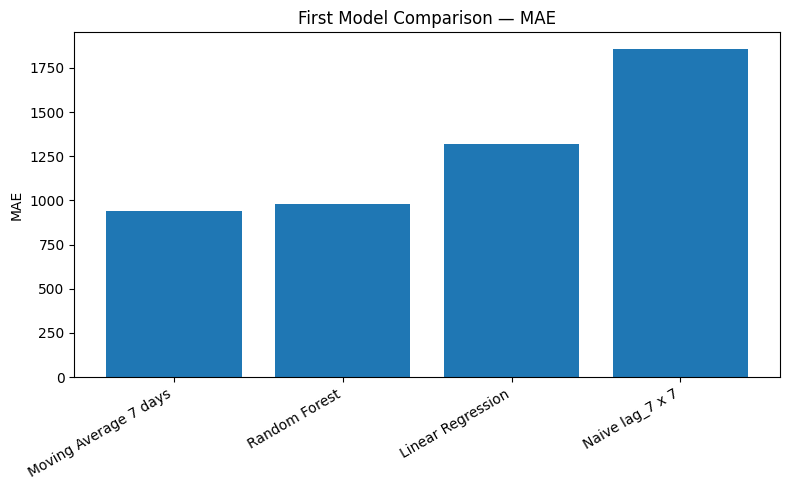

In [123]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("First Model Comparison — MAE")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### First Results Interpretation

This first experiment compares simple baseline methods with machine learning regression models using the same time-based train/test split.

The baseline models provide a reference level of performance. The machine learning models are then evaluated to check whether they improve the prediction of future category-level sales.

At this stage, the objective is not to select a final model, but to establish a clean first benchmark. The next experiments will test additional models such as ARMA, SARIMA, XGBoost, and different values of X and Y.